In [1]:
# ============================================================
# Import Required Libraries
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import os
import json
import time
import joblib
import numpy as np
import pandas as pd

import plotly.express as px
import plotly.graph_objects as go

from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import (
    Ridge,
    Lasso
)

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.model_selection import (
    KFold,
    GridSearchCV,
    cross_validate
)

from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# ============================================================
# Define Project Paths
# ============================================================

PROCESSED_DATA_DIR = "../data/processed"
MODEL_DIR = "../models"
REPORT_DIR = "../reports"

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(REPORT_DIR, exist_ok=True)

X_TRAIN_PATH = os.path.join(
    PROCESSED_DATA_DIR,
    "X_train.csv"
)

X_TEST_PATH = os.path.join(
    PROCESSED_DATA_DIR,
    "X_test.csv"
)

Y_TRAIN_PATH = os.path.join(
    PROCESSED_DATA_DIR,
    "y_train.csv"
)

Y_TEST_PATH = os.path.join(
    PROCESSED_DATA_DIR,
    "y_test.csv"
)

BASELINE_METRICS_PATH = os.path.join(
    REPORT_DIR,
    "model_metrics.csv"
)

PREPROCESSING_METADATA_PATH = os.path.join(
    MODEL_DIR,
    "preprocessing_metadata.pkl"
)

print("Project paths configured successfully.")

Project paths configured successfully.


In [3]:
# ============================================================
# Load Training and Testing Data
# ============================================================

X_train = pd.read_csv(X_TRAIN_PATH)
X_test = pd.read_csv(X_TEST_PATH)

y_train = pd.read_csv(
    Y_TRAIN_PATH
)["Sales"]

y_test = pd.read_csv(
    Y_TEST_PATH
)["Sales"]

print("Processed datasets loaded successfully.")

Processed datasets loaded successfully.


In [4]:
# ============================================================
# Validate Dataset Alignment
# ============================================================

assert len(X_train) == len(y_train), (
    "Training features and target are not aligned."
)

assert len(X_test) == len(y_test), (
    "Testing features and target are not aligned."
)

assert X_train.columns.tolist() == X_test.columns.tolist(), (
    "Training and testing feature columns do not match."
)

assert not X_train.isnull().any().any(), (
    "Missing values found in X_train."
)

assert not X_test.isnull().any().any(), (
    "Missing values found in X_test."
)

assert not y_train.isnull().any(), (
    "Missing values found in y_train."
)

assert not y_test.isnull().any(), (
    "Missing values found in y_test."
)

print("All dataset validation checks passed.")

All dataset validation checks passed.


In [5]:
# ============================================================
# Dataset Shapes
# ============================================================

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)

X_train shape: (160, 3)
X_test shape : (40, 3)
y_train shape: (160,)
y_test shape : (40,)


In [6]:
# ============================================================
# Load Preprocessing Metadata
# ============================================================

if os.path.exists(
    PREPROCESSING_METADATA_PATH
):
    preprocessing_metadata = joblib.load(
        PREPROCESSING_METADATA_PATH
    )
else:
    preprocessing_metadata = {
        "feature_columns": X_train.columns.tolist(),
        "target_column": "Sales",
        "random_state": 42
    }

display(preprocessing_metadata)

{'feature_columns': ['TV', 'Radio', 'Newspaper'],
 'target_column': 'Sales',
 'test_size': 0.2,
 'random_state': 42,
 'scaler': 'StandardScaler'}

In [7]:
# ============================================================
# Validate Feature Order
# ============================================================

feature_columns = preprocessing_metadata[
    "feature_columns"
]

assert X_train.columns.tolist() == feature_columns, (
    "Training feature order does not match metadata."
)

assert X_test.columns.tolist() == feature_columns, (
    "Testing feature order does not match metadata."
)

print("Feature order validated successfully.")

Feature order validated successfully.


In [8]:
# ============================================================
# Load Baseline Metrics
# ============================================================

if not os.path.exists(
    BASELINE_METRICS_PATH
):
    raise FileNotFoundError(
        "Baseline metrics were not found. "
        "Run Notebook 4 before Notebook 5."
    )

baseline_results = pd.read_csv(
    BASELINE_METRICS_PATH
)

display(
    baseline_results.style.format({
        "Train R2": "{:.4f}",
        "Test R2": "{:.4f}",
        "R2 Gap": "{:.4f}",
        "Test MAE": "{:.4f}",
        "Test RMSE": "{:.4f}",
        "Test MAPE (%)": "{:.2f}%",
        "CV Mean R2": "{:.4f}",
        "CV Mean MAE": "{:.4f}",
        "CV Mean RMSE": "{:.4f}",
        "CV RMSE Std": "{:.4f}"
    })
)

,Model,Train R2,Test R2,R2 Gap,Test MAE,Test RMSE,Test MAPE (%),CV Mean R2,CV R2 Std,CV Mean MAE,CV Mean RMSE,CV RMSE Std,Training Time (Seconds)
0,Random Forest,0.9917,0.9549,0.0368,0.9031,1.1801,7.49%,0.9321,0.016601,0.9504,1.3068,0.2332,5.470466
1,XGBoost,0.9942,0.9517,0.0424,0.9258,1.2212,7.74%,0.9124,0.026427,1.1081,1.4661,0.2276,1.337825
2,Lasso Regression,0.9001,0.9059,-0.0058,1.2725,1.7050,10.87%,0.8797,0.054539,1.2777,1.6789,0.2787,7.220278
3,Ridge Regression,0.9001,0.9057,-0.0055,1.2734,1.7074,10.91%,0.8796,0.054197,1.2791,1.6805,0.2810,23.411603
4,Linear Regression,0.9001,0.9059,-0.0058,1.2748,1.7052,10.88%,0.8793,0.055254,1.2782,1.6808,0.2825,8.037649
5,Decision Tree,1.0000,0.8899,0.1101,1.2400,1.8445,11.48%,0.8784,0.007156,1.2494,1.7587,0.1999,0.505383


In [9]:
# ============================================================
# Regression Metrics Function
# ============================================================

def calculate_regression_metrics(
    y_actual,
    y_predicted
):
    """
    Calculate common regression metrics.
    """

    r2 = r2_score(
        y_actual,
        y_predicted
    )

    mae = mean_absolute_error(
        y_actual,
        y_predicted
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_actual,
            y_predicted
        )
    )

    actual_array = np.asarray(
        y_actual
    )

    predicted_array = np.asarray(
        y_predicted
    )

    non_zero_mask = actual_array != 0

    if non_zero_mask.any():
        mape = np.mean(
            np.abs(
                (
                    actual_array[non_zero_mask]
                    - predicted_array[non_zero_mask]
                )
                / actual_array[non_zero_mask]
            )
        ) * 100
    else:
        mape = np.nan

    return {
        "R2": r2,
        "MAE": mae,
        "RMSE": rmse,
        "MAPE": mape
    }

In [10]:
# ============================================================
# Configure Cross-Validation
# ============================================================

RANDOM_STATE = 42

cross_validation = KFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

scoring = {
    "r2": "r2",
    "mae": "neg_mean_absolute_error",
    "mse": "neg_mean_squared_error"
}

print("Cross-validation configured successfully.")

Cross-validation configured successfully.


In [11]:
# ============================================================
# Define Tuning Candidates
# ============================================================

tuning_candidates = {
    "Ridge Regression": {
        "estimator": Pipeline([
            (
                "scaler",
                StandardScaler()
            ),
            (
                "model",
                Ridge()
            )
        ]),
        "parameters": {
            "model__alpha": [
                0.001,
                0.01,
                0.1,
                1.0,
                10.0,
                100.0
            ]
        }
    },

    "Lasso Regression": {
        "estimator": Pipeline([
            (
                "scaler",
                StandardScaler()
            ),
            (
                "model",
                Lasso(
                    max_iter=20000
                )
            )
        ]),
        "parameters": {
            "model__alpha": [
                0.0001,
                0.001,
                0.01,
                0.05,
                0.1,
                0.5,
                1.0
            ]
        }
    },

    "Decision Tree": {
        "estimator": DecisionTreeRegressor(
            random_state=RANDOM_STATE
        ),
        "parameters": {
            "max_depth": [
                None,
                2,
                3,
                4,
                5,
                6
            ],
            "min_samples_split": [
                2,
                5,
                10,
                15
            ],
            "min_samples_leaf": [
                1,
                2,
                4,
                6
            ],
            "max_features": [
                None,
                "sqrt",
                "log2"
            ]
        }
    },

    "Random Forest": {
        "estimator": RandomForestRegressor(
            random_state=RANDOM_STATE,
            n_jobs=-1
        ),
        "parameters": {
            "n_estimators": [
                200,
                400
            ],
            "max_depth": [
                None,
                4,
                6,
                8
            ],
            "min_samples_split": [
                2,
                5,
                10
            ],
            "min_samples_leaf": [
                1,
                2,
                4
            ],
            "max_features": [
                1.0,
                "sqrt"
            ]
        }
    }
}

print("Core tuning candidates defined successfully.")

Core tuning candidates defined successfully.


In [12]:
# ============================================================
# Add XGBoost Tuning Candidate if Available
# ============================================================

xgboost_available = False

try:
    from xgboost import XGBRegressor

    tuning_candidates["XGBoost"] = {
        "estimator": XGBRegressor(
            objective="reg:squarederror",
            random_state=RANDOM_STATE,
            n_jobs=-1
        ),
        "parameters": {
            "n_estimators": [
                100,
                200,
                300
            ],
            "learning_rate": [
                0.01,
                0.05,
                0.1
            ],
            "max_depth": [
                2,
                3,
                4
            ],
            "subsample": [
                0.8,
                1.0
            ],
            "colsample_bytree": [
                0.8,
                1.0
            ],
            "reg_alpha": [
                0.0,
                0.1
            ],
            "reg_lambda": [
                1.0,
                5.0
            ]
        }
    }

    xgboost_available = True

    print("XGBoost tuning candidate added.")

except ImportError:
    print(
        "XGBoost is not installed. "
        "The remaining model families will be tuned."
    )

XGBoost tuning candidate added.


In [15]:
# ============================================================
# Define Tuning Candidates
# ============================================================

tuning_candidates = {
    "Ridge Regression": {
        "estimator": Pipeline([
            (
                "scaler",
                StandardScaler()
            ),
            (
                "model",
                Ridge()
            )
        ]),
        "parameters": {
            "model__alpha": [
                0.001,
                0.01,
                0.1,
                1.0,
                10.0,
                100.0
            ]
        }
    },

    "Lasso Regression": {
        "estimator": Pipeline([
            (
                "scaler",
                StandardScaler()
            ),
            (
                "model",
                Lasso(
                    max_iter=20000
                )
            )
        ]),
        "parameters": {
            "model__alpha": [
                0.0001,
                0.001,
                0.01,
                0.05,
                0.1,
                0.5,
                1.0
            ]
        }
    },

    "Decision Tree": {
        "estimator": DecisionTreeRegressor(
            random_state=RANDOM_STATE
        ),
        "parameters": {
            "max_depth": [
                None,
                2,
                3,
                4,
                5,
                6
            ],
            "min_samples_split": [
                2,
                5,
                10
            ],
            "min_samples_leaf": [
                1,
                2,
                4
            ],
            "max_features": [
                None
            ]
        }
    },

    "Random Forest": {
        "estimator": RandomForestRegressor(
            random_state=RANDOM_STATE,
            n_jobs=-1
        ),
        "parameters": {
            "n_estimators": [
                100,
                200
            ],
            "max_depth": [
                None,
                5,
                10
            ],
            "min_samples_split": [
                2,
                5
            ],
            "min_samples_leaf": [
                1,
                2
            ],
            "max_features": [
                1.0
            ]
        }
    }
}

print("Core tuning candidates defined successfully.")

Core tuning candidates defined successfully.


In [16]:
# ============================================================
# Add XGBoost Tuning Candidate if Available
# ============================================================

xgboost_available = False

try:
    from xgboost import XGBRegressor

    tuning_candidates["XGBoost"] = {
        "estimator": XGBRegressor(
            objective="reg:squarederror",
            random_state=RANDOM_STATE,
            n_jobs=1
        ),
        "parameters": {
            "n_estimators": [
                100,
                200
            ],
            "learning_rate": [
                0.05,
                0.1
            ],
            "max_depth": [
                2,
                3
            ],
            "subsample": [
                0.8,
                1.0
            ],
            "colsample_bytree": [
                0.8,
                1.0
            ]
        }
    }

    xgboost_available = True

    print("XGBoost tuning candidate added.")

except ImportError:
    print(
        "XGBoost is not installed. "
        "The remaining model families will be tuned."
    )


XGBoost tuning candidate added.


In [17]:
# ============================================================
# Tune All Candidate Models
# ============================================================

tuning_summary_records = []
tuned_models = {}
grid_search_objects = {}

for model_name, model_configuration in tuning_candidates.items():

    print("=" * 75)
    print(f"Tuning: {model_name}")
    print("=" * 75)

    start_time = time.perf_counter()

    grid_search = GridSearchCV(
        estimator=model_configuration["estimator"],
        param_grid=model_configuration["parameters"],
        scoring="neg_mean_squared_error",
        cv=cross_validation,
        n_jobs=-1,
        refit=True,
        return_train_score=False,
        verbose=1
    )

    grid_search.fit(
        X_train,
        y_train
    )

    elapsed_time = (
        time.perf_counter()
        - start_time
    )

    best_estimator = grid_search.best_estimator_

    best_cv_rmse = np.sqrt(
        -grid_search.best_score_
    )

    train_predictions = best_estimator.predict(
        X_train
    )

    test_predictions = best_estimator.predict(
        X_test
    )

    train_metrics = calculate_regression_metrics(
        y_train,
        train_predictions
    )

    test_metrics = calculate_regression_metrics(
        y_test,
        test_predictions
    )

    tuning_summary_records.append({
        "Model": model_name,
        "Best Parameters": grid_search.best_params_,
        "Best CV RMSE": best_cv_rmse,
        "Train R2": train_metrics["R2"],
        "Test R2": test_metrics["R2"],
        "R2 Gap": (
            train_metrics["R2"]
            - test_metrics["R2"]
        ),
        "Test MAE": test_metrics["MAE"],
        "Test RMSE": test_metrics["RMSE"],
        "Test MAPE (%)": test_metrics["MAPE"],
        "Search Time (Seconds)": elapsed_time
    })

    tuned_models[model_name] = best_estimator
    grid_search_objects[model_name] = grid_search

    print("Best parameters:", grid_search.best_params_)
    print(f"Best CV RMSE: {best_cv_rmse:.4f}")
    print(f"Test RMSE   : {test_metrics['RMSE']:.4f}")
    print()

Tuning: Ridge Regression
Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best parameters: {'model__alpha': 1.0}
Best CV RMSE: 1.7038
Test RMSE   : 1.7074

Tuning: Lasso Regression
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Best parameters: {'model__alpha': 0.1}
Best CV RMSE: 1.6922
Test RMSE   : 1.7118

Tuning: Decision Tree
Fitting 5 folds for each of 54 candidates, totalling 270 fits
Best parameters: {'max_depth': 5, 'max_features': None, 'min_samples_leaf': 4, 'min_samples_split': 2}
Best CV RMSE: 1.6200
Test RMSE   : 1.2589

Tuning: Random Forest
Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best parameters: {'max_depth': 10, 'max_features': 1.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best CV RMSE: 1.3157
Test RMSE   : 1.2071

Tuning: XGBoost
Fitting 5 folds for each of 32 candidates, totalling 160 fits
Best parameters: {'colsample_bytree': 1.0, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200, 'sub

In [18]:
# ============================================================
# Tuned Model Comparison Table
# ============================================================

tuned_model_comparison = pd.DataFrame(
    tuning_summary_records
)

tuned_model_comparison = (
    tuned_model_comparison
    .sort_values(
        by="Best CV RMSE",
        ascending=True
    )
    .reset_index(drop=True)
)

display(
    tuned_model_comparison.style.format({
        "Best CV RMSE": "{:.4f}",
        "Train R2": "{:.4f}",
        "Test R2": "{:.4f}",
        "R2 Gap": "{:.4f}",
        "Test MAE": "{:.4f}",
        "Test RMSE": "{:.4f}",
        "Test MAPE (%)": "{:.2f}%",
        "Search Time (Seconds)": "{:.2f}"
    })
)

,Model,Best Parameters,Best CV RMSE,Train R2,Test R2,R2 Gap,Test MAE,Test RMSE,Test MAPE (%),Search Time (Seconds)
0,Random Forest,"{'max_depth': 10, 'max_features': 1.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}",1.3157,0.9914,0.9528,0.0385,0.9214,1.2071,7.66%,79.26
1,XGBoost,"{'colsample_bytree': 1.0, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}",1.3718,0.9907,0.9556,0.0351,0.8799,1.1715,7.77%,9.62
2,Decision Tree,"{'max_depth': 5, 'max_features': None, 'min_samples_leaf': 4, 'min_samples_split': 2}",1.6200,0.9596,0.9487,0.0109,0.9844,1.2589,8.12%,2.88
3,Lasso Regression,{'model__alpha': 0.1},1.6922,0.8993,0.9052,-0.0059,1.2701,1.7118,10.93%,0.58
4,Ridge Regression,{'model__alpha': 1.0},1.7038,0.9001,0.9057,-0.0055,1.2734,1.7074,10.91%,0.58


In [19]:
# ============================================================
# Cross Validation Summary
# ============================================================

tuned_cv_records = []

for model_name, tuned_model in tuned_models.items():

    cv_scores = cross_validate(
        estimator=clone(tuned_model),
        X=X_train,
        y=y_train,
        cv=cross_validation,
        scoring=scoring,
        n_jobs=-1
    )

    cv_r2 = cv_scores["test_r2"]
    cv_mae = -cv_scores["test_mae"]
    cv_rmse = np.sqrt(-cv_scores["test_mse"])

    tuned_cv_records.append({
        "Model": model_name,
        "CV Mean R2": cv_r2.mean(),
        "CV R2 Std": cv_r2.std(),
        "CV Mean MAE": cv_mae.mean(),
        "CV MAE Std": cv_mae.std(),
        "CV Mean RMSE": cv_rmse.mean(),
        "CV RMSE Std": cv_rmse.std()
    })

tuned_cv_summary = (
    pd.DataFrame(tuned_cv_records)
    .sort_values(
        by="CV Mean RMSE",
        ascending=True
    )
    .reset_index(drop=True)
)

display(
    tuned_cv_summary.style.format({
        "CV Mean R2": "{:.4f}",
        "CV R2 Std": "{:.4f}",
        "CV Mean MAE": "{:.4f}",
        "CV MAE Std": "{:.4f}",
        "CV Mean RMSE": "{:.4f}",
        "CV RMSE Std": "{:.4f}"
    })
)

,Model,CV Mean R2,CV R2 Std,CV Mean MAE,CV MAE Std,CV Mean RMSE,CV RMSE Std
0,Random Forest,0.9328,0.0126,0.9520,0.1084,1.3015,0.1927
1,XGBoost,0.9248,0.0206,1.0193,0.1043,1.3584,0.1911
2,Decision Tree,0.8981,0.0081,1.2284,0.1494,1.6097,0.1830
3,Lasso Regression,0.8820,0.0487,1.2826,0.1419,1.6729,0.2546
4,Ridge Regression,0.8796,0.0542,1.2791,0.1643,1.6805,0.2810


In [20]:
# ============================================================
# Baseline vs Tuned Comparison
# ============================================================

baseline_comparison = baseline_results[
    [
        "Model",
        "CV Mean RMSE",
        "Test RMSE",
        "Test R2"
    ]
].copy()

baseline_comparison = baseline_comparison.rename(
    columns={
        "CV Mean RMSE": "Baseline CV RMSE",
        "Test RMSE": "Baseline Test RMSE",
        "Test R2": "Baseline Test R2"
    }
)

tuned_comparison = (
    tuned_model_comparison[
        [
            "Model",
            "Test RMSE",
            "Test R2"
        ]
    ]
    .merge(
        tuned_cv_summary[
            [
                "Model",
                "CV Mean RMSE"
            ]
        ],
        on="Model",
        how="left"
    )
)

tuned_comparison = tuned_comparison.rename(
    columns={
        "CV Mean RMSE": "Tuned CV RMSE",
        "Test RMSE": "Tuned Test RMSE",
        "Test R2": "Tuned Test R2"
    }
)

baseline_vs_tuned = baseline_comparison.merge(
    tuned_comparison,
    on="Model"
)

baseline_vs_tuned[
    "CV RMSE Improvement"
] = (
    baseline_vs_tuned["Baseline CV RMSE"]
    -
    baseline_vs_tuned["Tuned CV RMSE"]
)

baseline_vs_tuned[
    "Test RMSE Improvement"
] = (
    baseline_vs_tuned["Baseline Test RMSE"]
    -
    baseline_vs_tuned["Tuned Test RMSE"]
)

display(
    baseline_vs_tuned.style.format({
        "Baseline CV RMSE": "{:.4f}",
        "Tuned CV RMSE": "{:.4f}",
        "CV RMSE Improvement": "{:.4f}",
        "Baseline Test RMSE": "{:.4f}",
        "Tuned Test RMSE": "{:.4f}",
        "Test RMSE Improvement": "{:.4f}",
        "Baseline Test R2": "{:.4f}",
        "Tuned Test R2": "{:.4f}"
    })
)

,Model,Baseline CV RMSE,Baseline Test RMSE,Baseline Test R2,Tuned Test RMSE,Tuned Test R2,Tuned CV RMSE,CV RMSE Improvement,Test RMSE Improvement
0,Random Forest,1.3068,1.1801,0.9549,1.2071,0.9528,1.3015,0.0053,-0.0271
1,XGBoost,1.4661,1.2212,0.9517,1.1715,0.9556,1.3584,0.1077,0.0498
2,Lasso Regression,1.6789,1.7050,0.9059,1.7118,0.9052,1.6729,0.0060,-0.0067
3,Ridge Regression,1.6805,1.7074,0.9057,1.7074,0.9057,1.6805,0.0000,0.0000
4,Decision Tree,1.7587,1.8445,0.8899,1.2589,0.9487,1.6097,0.1490,0.5856


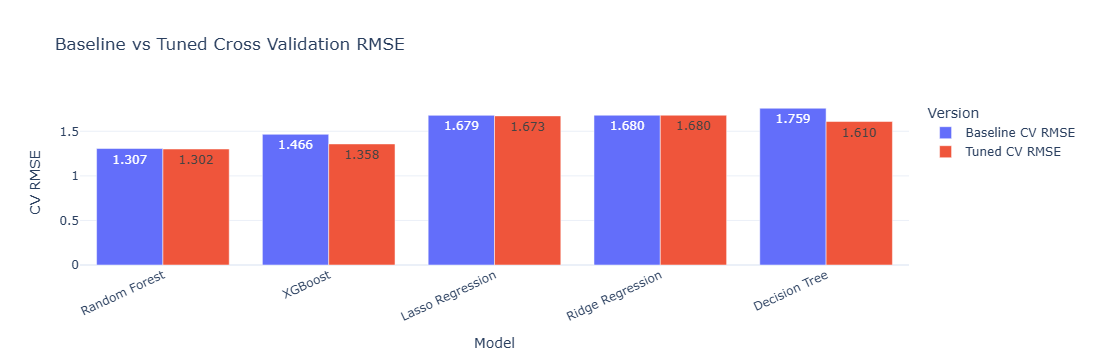

In [21]:
# ============================================================
# Baseline vs Tuned CV RMSE
# ============================================================

plot_df = baseline_vs_tuned[
    [
        "Model",
        "Baseline CV RMSE",
        "Tuned CV RMSE"
    ]
].melt(
    id_vars="Model",
    var_name="Version",
    value_name="CV RMSE"
)

fig = px.bar(
    plot_df,
    x="Model",
    y="CV RMSE",
    color="Version",
    barmode="group",
    text_auto=".3f",
    title="Baseline vs Tuned Cross Validation RMSE",
    template="plotly_white"
)

fig.update_layout(
    xaxis_tickangle=-25
)

fig.show()

In [22]:
# ============================================================
# Select Final Model
# ============================================================

best_index = tuned_cv_summary[
    "CV Mean RMSE"
].idxmin()

final_model_name = tuned_cv_summary.loc[
    best_index,
    "Model"
]

final_model = tuned_models[
    final_model_name
]

final_cv_rmse = tuned_cv_summary.loc[
    best_index,
    "CV Mean RMSE"
]

final_cv_r2 = tuned_cv_summary.loc[
    best_index,
    "CV Mean R2"
]

final_parameters = (
    grid_search_objects[
        final_model_name
    ].best_params_
)

print(f"Selected Final Model : {final_model_name}")
print(f"CV RMSE              : {final_cv_rmse:.4f}")
print(f"CV R²                : {final_cv_r2:.4f}")

print("\nBest Parameters")
print(final_parameters)



Selected Final Model : Random Forest
CV RMSE              : 1.3015
CV R²                : 0.9328

Best Parameters
{'max_depth': 10, 'max_features': 1.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}


In [23]:
# ============================================================
# Generate Predictions
# ============================================================

final_train_predictions = (
    final_model.predict(
        X_train
    )
)

final_test_predictions = (
    final_model.predict(
        X_test
    )
)

final_train_metrics = (
    calculate_regression_metrics(
        y_train,
        final_train_predictions
    )
)

final_test_metrics = (
    calculate_regression_metrics(
        y_test,
        final_test_predictions
    )
)

print("Predictions generated successfully.")

Predictions generated successfully.


In [24]:
# ============================================================
# Final Metrics
# ============================================================

final_metrics = pd.DataFrame({
    "Metric":[
        "R²",
        "MAE",
        "RMSE",
        "MAPE (%)"
    ],
    "Training":[
        final_train_metrics["R2"],
        final_train_metrics["MAE"],
        final_train_metrics["RMSE"],
        final_train_metrics["MAPE"]
    ],
    "Testing":[
        final_test_metrics["R2"],
        final_test_metrics["MAE"],
        final_test_metrics["RMSE"],
        final_test_metrics["MAPE"]
    ]
})

display(
    final_metrics.style.format({
        "Training":"{:.4f}",
        "Testing":"{:.4f}"
    })
)

,Metric,Training,Testing
0,R²,0.9914,0.9528
1,MAE,0.3363,0.9214
2,RMSE,0.4810,1.2071
3,MAPE (%),3.0423,7.6563


In [25]:
# ============================================================
# Generalization Gap
# ============================================================

generalization_gap = (
    final_train_metrics["R2"]
    -
    final_test_metrics["R2"]
)

print(
    f"Generalization Gap (R²): {generalization_gap:.4f}"
)

if generalization_gap < 0.05:
    print("✅ Excellent generalization")

elif generalization_gap < 0.15:
    print("⚠️ Moderate overfitting")

else:
    print("❌ High overfitting")

Generalization Gap (R²): 0.0385
✅ Excellent generalization


In [26]:
# ============================================================
# Prediction DataFrame
# ============================================================

final_predictions_df = X_test.copy()

final_predictions_df[
    "Actual Sales"
] = y_test.values

final_predictions_df[
    "Predicted Sales"
] = final_test_predictions

final_predictions_df[
    "Residual"
] = (
    final_predictions_df["Actual Sales"]
    -
    final_predictions_df["Predicted Sales"]
)

final_predictions_df[
    "Absolute Error"
] = (
    final_predictions_df["Residual"]
    .abs()
)

final_predictions_df[
    "Squared Error"
] = (
    final_predictions_df["Residual"] ** 2
)

display(
    final_predictions_df
    .head(10)
    .style
    .format({
        "Actual Sales":"{:.2f}",
        "Predicted Sales":"{:.2f}",
        "Residual":"{:.2f}",
        "Absolute Error":"{:.2f}",
        "Squared Error":"{:.3f}"
    })
)

,TV,Radio,Newspaper,Actual Sales,Predicted Sales,Residual,Absolute Error,Squared Error
0,163.300000,31.600000,52.900000,16.90,17.29,-0.39,0.39,0.150
1,195.400000,47.700000,52.900000,22.40,22.54,-0.14,0.14,0.020
2,292.900000,28.300000,43.200000,21.40,19.72,1.68,1.68,2.824
3,11.700000,36.900000,45.200000,7.30,6.78,0.52,0.52,0.266
4,220.300000,49.000000,3.200000,24.70,22.87,1.83,1.83,3.364
5,75.100000,35.000000,52.700000,12.60,13.48,-0.88,0.88,0.773
6,216.800000,43.900000,27.200000,22.30,22.69,-0.39,0.39,0.149
7,50.000000,11.600000,18.400000,8.40,9.58,-1.18,1.18,1.391
8,222.400000,3.400000,13.100000,16.50,16.89,-0.39,0.39,0.150
9,175.100000,22.500000,31.500000,16.10,16.82,-0.72,0.72,0.517


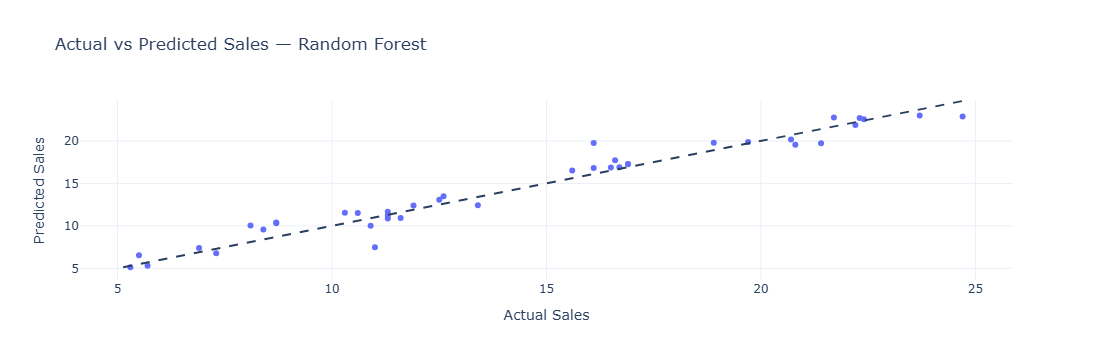

In [27]:
# ============================================================
# Actual vs Predicted Sales
# ============================================================

minimum_value = min(
    final_predictions_df[
        "Actual Sales"
    ].min(),
    final_predictions_df[
        "Predicted Sales"
    ].min()
)

maximum_value = max(
    final_predictions_df[
        "Actual Sales"
    ].max(),
    final_predictions_df[
        "Predicted Sales"
    ].max()
)

fig = px.scatter(
    final_predictions_df,
    x="Actual Sales",
    y="Predicted Sales",
    hover_data=[
        "TV",
        "Radio",
        "Newspaper",
        "Residual",
        "Absolute Error"
    ],
    title=(
        f"Actual vs Predicted Sales — "
        f"{final_model_name}"
    ),
    template="plotly_white"
)

fig.add_shape(
    type="line",
    x0=minimum_value,
    y0=minimum_value,
    x1=maximum_value,
    y1=maximum_value,
    line=dict(
        dash="dash"
    )
)

fig.update_layout(
    xaxis_title="Actual Sales",
    yaxis_title="Predicted Sales"
)

fig.show()

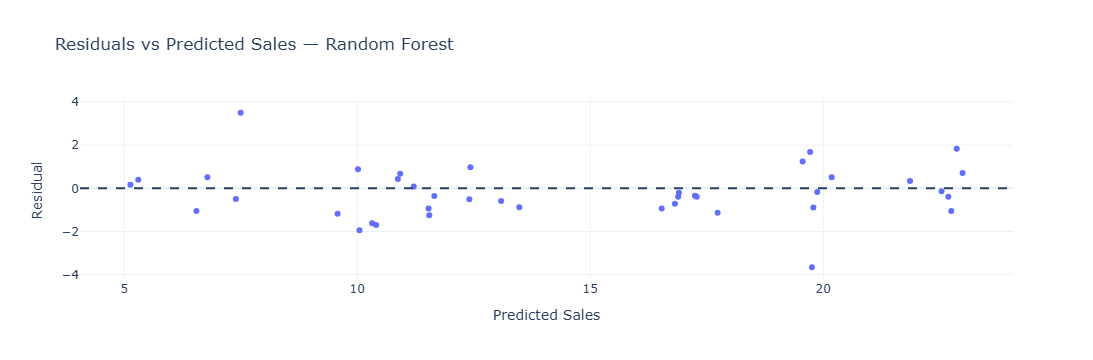

In [28]:
# ============================================================
# Residuals vs Predicted Sales
# ============================================================

fig = px.scatter(
    final_predictions_df,
    x="Predicted Sales",
    y="Residual",
    hover_data=[
        "Actual Sales",
        "TV",
        "Radio",
        "Newspaper",
        "Absolute Error"
    ],
    title=(
        f"Residuals vs Predicted Sales — "
        f"{final_model_name}"
    ),
    template="plotly_white"
)

fig.add_hline(
    y=0,
    line_dash="dash"
)

fig.update_layout(
    xaxis_title="Predicted Sales",
    yaxis_title="Residual"
)

fig.show()

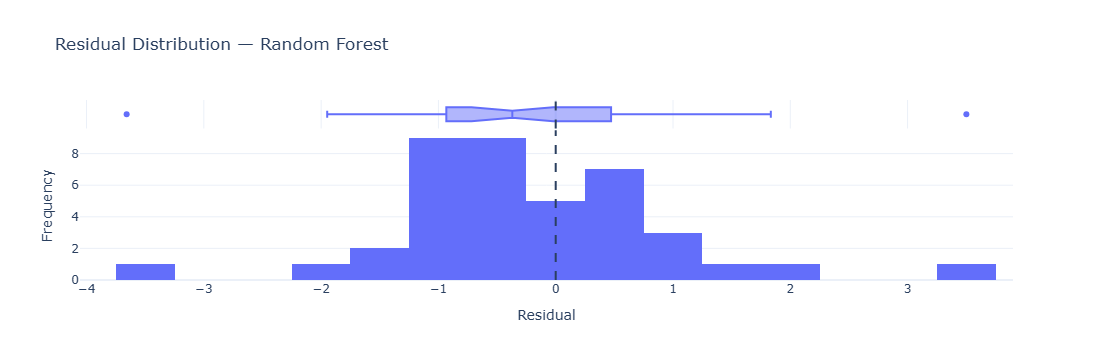

In [29]:
# ============================================================
# Residual Distribution
# ============================================================

fig = px.histogram(
    final_predictions_df,
    x="Residual",
    nbins=15,
    marginal="box",
    title=(
        f"Residual Distribution — "
        f"{final_model_name}"
    ),
    template="plotly_white"
)

fig.add_vline(
    x=0,
    line_dash="dash"
)

fig.update_layout(
    xaxis_title="Residual",
    yaxis_title="Frequency"
)

fig.show()

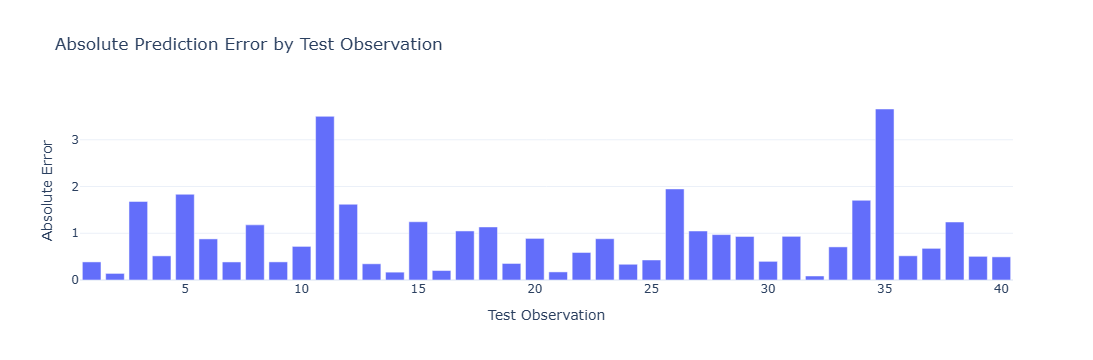

In [30]:
# ============================================================
# Absolute Error by Test Observation
# ============================================================

error_by_observation = (
    final_predictions_df
    .reset_index(drop=True)
    .reset_index()
    .rename(
        columns={
            "index": "Observation"
        }
    )
)

error_by_observation[
    "Observation"
] = (
    error_by_observation[
        "Observation"
    ] + 1
)

fig = px.bar(
    error_by_observation,
    x="Observation",
    y="Absolute Error",
    hover_data=[
        "Actual Sales",
        "Predicted Sales",
        "TV",
        "Radio",
        "Newspaper"
    ],
    title="Absolute Prediction Error by Test Observation",
    template="plotly_white"
)

fig.update_layout(
    xaxis_title="Test Observation",
    yaxis_title="Absolute Error"
)

fig.show()

In [31]:
# ============================================================
# Largest Prediction Errors
# ============================================================

largest_errors = (
    final_predictions_df
    .sort_values(
        by="Absolute Error",
        ascending=False
    )
    .head(10)
    .reset_index(drop=True)
)

display(
    largest_errors.style.format({
        "TV": "{:.2f}",
        "Radio": "{:.2f}",
        "Newspaper": "{:.2f}",
        "Actual Sales": "{:.2f}",
        "Predicted Sales": "{:.2f}",
        "Residual": "{:.2f}",
        "Absolute Error": "{:.2f}",
        "Squared Error": "{:.3f}"
    })
)

,TV,Radio,Newspaper,Actual Sales,Predicted Sales,Residual,Absolute Error,Squared Error
0,280.70,13.90,37.00,16.10,19.76,-3.66,3.66,13.381
1,31.50,24.60,2.20,11.00,7.50,3.50,3.50,12.257
2,53.50,2.00,21.40,8.10,10.05,-1.95,1.95,3.796
3,220.30,49.00,3.20,24.70,22.87,1.83,1.83,3.364
4,16.90,43.70,89.40,8.70,10.41,-1.71,1.71,2.907
5,292.90,28.30,43.20,21.40,19.72,1.68,1.68,2.824
6,56.20,5.70,29.70,8.70,10.32,-1.62,1.62,2.625
7,139.50,2.10,26.60,10.30,11.55,-1.25,1.25,1.553
8,273.70,28.90,59.70,20.80,19.56,1.24,1.24,1.540
9,50.00,11.60,18.40,8.40,9.58,-1.18,1.18,1.391


In [32]:
# ============================================================
# Extract Final Estimator
# ============================================================

if isinstance(
    final_model,
    Pipeline
):
    underlying_model = final_model.named_steps[
        "model"
    ]
else:
    underlying_model = final_model

print(
    "Underlying estimator:",
    type(underlying_model).__name__
)

Underlying estimator: RandomForestRegressor


In [33]:
# ============================================================
# Generate Feature Importance or Coefficients
# ============================================================

feature_interpretation = None
interpretation_type = None
value_column = None

if hasattr(
    underlying_model,
    "feature_importances_"
):
    feature_interpretation = pd.DataFrame({
        "Feature": feature_columns,
        "Importance": (
            underlying_model
            .feature_importances_
        )
    })

    interpretation_type = "Feature Importance"
    value_column = "Importance"

elif hasattr(
    underlying_model,
    "coef_"
):
    feature_interpretation = pd.DataFrame({
        "Feature": feature_columns,
        "Coefficient": np.ravel(
            underlying_model.coef_
        )
    })

    interpretation_type = "Coefficient"
    value_column = "Coefficient"

else:
    print(
        "The selected model does not expose "
        "feature importance or coefficients."
    )

,Feature,Importance
0,TV,0.8453
1,Radio,0.1368
2,Newspaper,0.0179


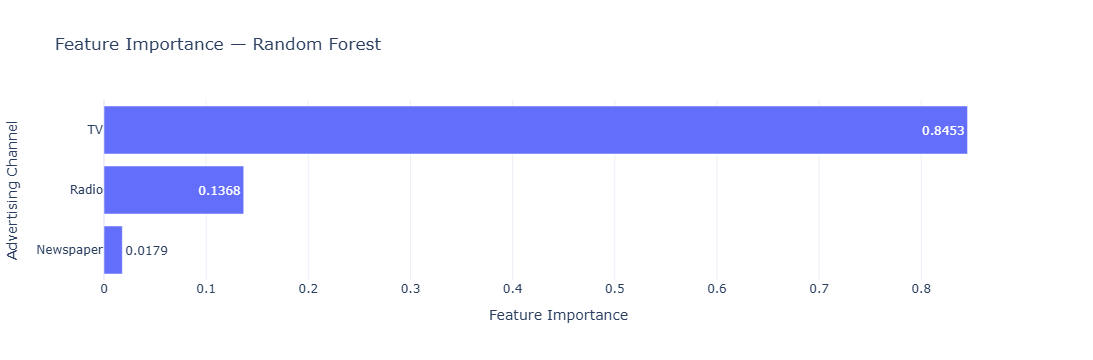

In [34]:
# ============================================================
# Display and Plot Feature Interpretation
# ============================================================

if feature_interpretation is not None:

    if interpretation_type == "Feature Importance":
        feature_interpretation = (
            feature_interpretation
            .sort_values(
                by=value_column,
                ascending=False
            )
            .reset_index(drop=True)
        )

    else:
        feature_interpretation[
            "Absolute Coefficient"
        ] = feature_interpretation[
            value_column
        ].abs()

        feature_interpretation = (
            feature_interpretation
            .sort_values(
                by="Absolute Coefficient",
                ascending=False
            )
            .reset_index(drop=True)
        )

    display(
        feature_interpretation.style.format({
            column: "{:.4f}"
            for column in feature_interpretation.columns
            if column != "Feature"
        })
    )

    fig = px.bar(
        feature_interpretation,
        x=value_column,
        y="Feature",
        orientation="h",
        text_auto=".4f",
        title=(
            f"{interpretation_type} — "
            f"{final_model_name}"
        ),
        template="plotly_white"
    )

    fig.update_layout(
        xaxis_title=interpretation_type,
        yaxis_title="Advertising Channel",
        yaxis={
            "categoryorder": "total ascending"
        }
    )

    fig.show()

In [35]:
# ============================================================
# Save Final Deployment Model
# ============================================================

FINAL_MODEL_PATH = os.path.join(
    MODEL_DIR,
    "final_model.pkl"
)

joblib.dump(
    final_model,
    FINAL_MODEL_PATH
)

print(
    "Final model saved successfully at:",
    FINAL_MODEL_PATH
)

Final model saved successfully at: ../models\final_model.pkl


In [36]:
# ============================================================
# Save Final Model Metadata
# ============================================================

final_model_metadata = {
    "project_name": "AdIntel",
    "model_name": final_model_name,
    "feature_columns": feature_columns,
    "target_column": "Sales",
    "selection_metric": "Five-fold CV RMSE",
    "cv_mean_rmse": float(final_cv_rmse),
    "cv_mean_r2": float(final_cv_r2),
    "test_r2": float(
        final_test_metrics["R2"]
    ),
    "test_mae": float(
        final_test_metrics["MAE"]
    ),
    "test_rmse": float(
        final_test_metrics["RMSE"]
    ),
    "test_mape_percent": float(
        final_test_metrics["MAPE"]
    ),
    "generalization_gap_r2": float(
        generalization_gap
    ),
    "best_parameters": final_parameters,
    "random_state": RANDOM_STATE,
    "cross_validation_folds": 5
}

FINAL_METADATA_PATH = os.path.join(
    MODEL_DIR,
    "final_model_metadata.pkl"
)

joblib.dump(
    final_model_metadata,
    FINAL_METADATA_PATH
)

display(final_model_metadata)


{'project_name': 'AdIntel',
 'model_name': 'Random Forest',
 'feature_columns': ['TV', 'Radio', 'Newspaper'],
 'target_column': 'Sales',
 'selection_metric': 'Five-fold CV RMSE',
 'cv_mean_rmse': 1.3015404052250497,
 'cv_mean_r2': 0.932767936098333,
 'test_r2': 0.952844707348761,
 'test_mae': 0.9214009920634915,
 'test_rmse': 1.2071248542488062,
 'test_mape_percent': 7.656257675988057,
 'generalization_gap_r2': 0.03852349649222997,
 'best_parameters': {'max_depth': 10,
  'max_features': 1.0,
  'min_samples_leaf': 1,
  'min_samples_split': 2,
  'n_estimators': 100},
 'random_state': 42,
 'cross_validation_folds': 5}

In [37]:
# ============================================================
# Save Human-Readable Metadata as JSON
# ============================================================

FINAL_METADATA_JSON_PATH = os.path.join(
    REPORT_DIR,
    "final_model_metadata.json"
)

with open(
    FINAL_METADATA_JSON_PATH,
    "w",
    encoding="utf-8"
) as metadata_file:
    json.dump(
        final_model_metadata,
        metadata_file,
        indent=4,
        default=str
    )

print(
    "JSON metadata saved successfully at:",
    FINAL_METADATA_JSON_PATH
)

JSON metadata saved successfully at: ../reports\final_model_metadata.json


In [38]:
# ============================================================
# Save Tuned Model Metrics
# ============================================================

TUNED_RESULTS_PATH = os.path.join(
    REPORT_DIR,
    "tuned_model_metrics.csv"
)

tuned_model_comparison.to_csv(
    TUNED_RESULTS_PATH,
    index=False
)

print(
    "Tuned model metrics saved successfully at:",
    TUNED_RESULTS_PATH
)

Tuned model metrics saved successfully at: ../reports\tuned_model_metrics.csv


In [39]:
# ============================================================
# Save Tuned Cross-Validation Results
# ============================================================

TUNED_CV_PATH = os.path.join(
    REPORT_DIR,
    "tuned_cross_validation_results.csv"
)

tuned_cv_summary.to_csv(
    TUNED_CV_PATH,
    index=False
)

print(
    "Tuned cross-validation results saved at:",
    TUNED_CV_PATH
)

Tuned cross-validation results saved at: ../reports\tuned_cross_validation_results.csv


In [40]:
# ============================================================
# Save Baseline vs Tuned Comparison
# ============================================================

BASELINE_TUNED_PATH = os.path.join(
    REPORT_DIR,
    "baseline_vs_tuned_models.csv"
)

baseline_vs_tuned.to_csv(
    BASELINE_TUNED_PATH,
    index=False
)

print(
    "Baseline vs tuned comparison saved at:",
    BASELINE_TUNED_PATH
)


Baseline vs tuned comparison saved at: ../reports\baseline_vs_tuned_models.csv


In [41]:
# ============================================================
# Save Final Model Predictions
# ============================================================

FINAL_PREDICTIONS_PATH = os.path.join(
    REPORT_DIR,
    "final_model_predictions.csv"
)

final_predictions_df.to_csv(
    FINAL_PREDICTIONS_PATH,
    index=False
)

print(
    "Final predictions saved successfully at:",
    FINAL_PREDICTIONS_PATH
)

Final predictions saved successfully at: ../reports\final_model_predictions.csv


In [42]:
# ============================================================
# Save Feature Importance or Coefficients
# ============================================================

FEATURE_INTERPRETATION_PATH = None

if feature_interpretation is not None:

    FEATURE_INTERPRETATION_PATH = os.path.join(
        REPORT_DIR,
        "feature_importance.csv"
    )

    feature_interpretation.to_csv(
        FEATURE_INTERPRETATION_PATH,
        index=False
    )

    print(
        "Feature interpretation saved at:",
        FEATURE_INTERPRETATION_PATH
    )

else:
    print(
        "No feature interpretation file was created "
        "because the selected model does not expose "
        "feature importance or coefficients."
    )

Feature interpretation saved at: ../reports\feature_importance.csv


In [43]:
# ============================================================
# Reload and Validate Final Model
# ============================================================

reloaded_final_model = joblib.load(
    FINAL_MODEL_PATH
)

reloaded_predictions = (
    reloaded_final_model.predict(
        X_test
    )
)

assert np.allclose(
    final_test_predictions,
    reloaded_predictions
), (
    "Reloaded model predictions do not match "
    "the original final predictions."
)

print(
    "Final model reloaded and validated successfully."
)

Final model reloaded and validated successfully.


In [44]:
# ============================================================
# Test One Deployment-Style Prediction
# ============================================================

sample_input = pd.DataFrame({
    "TV": [150.0],
    "Radio": [30.0],
    "Newspaper": [20.0]
})

sample_input = sample_input[
    feature_columns
]

sample_prediction = (
    reloaded_final_model.predict(
        sample_input
    )[0]
)

print("Sample advertising budget:")
display(sample_input)

print(
    f"Predicted Sales: {sample_prediction:.2f}"
)

Sample advertising budget:


,TV,Radio,Newspaper
0,150.0,30.0,20.0


Predicted Sales: 15.57


In [45]:
# ============================================================
# Validate Sample Prediction
# ============================================================

assert np.isfinite(
    sample_prediction
), (
    "The sample prediction is not a valid finite value."
)

assert sample_input.columns.tolist() == feature_columns, (
    "Sample input feature order does not match "
    "the trained model feature order."
)

print("Sample prediction validation passed.")

Sample prediction validation passed.


In [46]:
# ============================================================
# Verify Notebook 5 Output Files
# ============================================================

expected_files = [
    FINAL_MODEL_PATH,
    FINAL_METADATA_PATH,
    FINAL_METADATA_JSON_PATH,
    TUNED_RESULTS_PATH,
    TUNED_CV_PATH,
    BASELINE_TUNED_PATH,
    FINAL_PREDICTIONS_PATH
]

if FEATURE_INTERPRETATION_PATH is not None:
    expected_files.append(
        FEATURE_INTERPRETATION_PATH
    )

file_verification = pd.DataFrame({
    "File": [
        os.path.basename(path)
        for path in expected_files
    ],
    "Saved": [
        os.path.exists(path)
        for path in expected_files
    ]
})

display(file_verification)

,File,Saved
0,final_model.pkl,True
1,final_model_metadata.pkl,True
2,final_model_metadata.json,True
3,tuned_model_metrics.csv,True
4,tuned_cross_validation_results.csv,True
5,baseline_vs_tuned_models.csv,True
6,final_model_predictions.csv,True
7,feature_importance.csv,True


In [47]:
# ============================================================
# Final Modeling Summary
# ============================================================

final_modeling_summary = pd.DataFrame({
    "Item": [
        "Models tuned",
        "Selection metric",
        "Final model",
        "Best parameters",
        "Cross-validation RMSE",
        "Cross-validation R²",
        "Test R²",
        "Test MAE",
        "Test RMSE",
        "Test MAPE",
        "Generalization gap",
        "Final model saved",
        "Reload validation passed",
        "Sample prediction passed"
    ],
    "Value": [
        len(tuning_candidates),
        "Five-fold CV RMSE",
        final_model_name,
        str(final_parameters),
        round(
            final_cv_rmse,
            4
        ),
        round(
            final_cv_r2,
            4
        ),
        round(
            final_test_metrics["R2"],
            4
        ),
        round(
            final_test_metrics["MAE"],
            4
        ),
        round(
            final_test_metrics["RMSE"],
            4
        ),
        (
            f"{final_test_metrics['MAPE']:.2f}%"
        ),
        round(
            generalization_gap,
            4
        ),
        os.path.exists(
            FINAL_MODEL_PATH
        ),
        True,
        True
    ]
})

display(final_modeling_summary)

,Item,Value
0,Models tuned,5
1,Selection metric,Five-fold CV RMSE
2,Final model,Random Forest
3,Best parameters,"{'max_depth': 10, 'max_features': 1.0, 'min_sa..."
4,Cross-validation RMSE,1.3015
5,Cross-validation R²,0.9328
6,Test R²,0.9528
7,Test MAE,0.9214
8,Test RMSE,1.2071
9,Test MAPE,7.66%
